<a href="https://colab.research.google.com/github/fathanick/Artificial-Intelligence-Course/blob/main/02_Tutorial_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Data Preprocessing dengan Python

Pada tutorial ini, kita akan mempelajari teknik-teknik **data preprocessing**, yaitu proses mengubah data mentah menjadi format yang bersih dan terstruktur sehingga siap digunakan untuk analisis data atau pelatihan model machine learning.

### Apa yang akan kita pelajari?

1. Data Cleaning (membersihkan data)
2. Data Integration (menggabungkan data dari berbagai sumber)
3. Data Transformation (scaling, encoding)
4. Data Reduction (seleksi fitur, PCA)
5. Outlier Detection (deteksi dan penanganan outlier)
6. Preprocessing Pipeline dengan scikit-learn

### Prasyarat

- Pemahaman dasar Python (variabel, fungsi, loop)
- Familiar dengan library pandas dan NumPy

### Estimasi waktu: 60-90 menit

---

> **Referensi:** Tutorial ini disusun berdasarkan materi dari [DataCamp - Data Preprocessing: A Complete Guide](https://www.datacamp.com/blog/data-preprocessing).

## Setup: Import Library

Kita mulai dengan mengimpor semua library yang akan digunakan sepanjang tutorial ini. Pastikan library berikut sudah terinstal di environment kalian. Jika belum, jalankan `pip install pandas numpy scikit-learn scipy matplotlib seaborn` di terminal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library dari scikit-learn untuk preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy import stats

# Atur tampilan pandas agar lebih rapi
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Semua library berhasil diimpor!')

Semua library berhasil diimpor!


## 1. Data Cleaning

Data cleaning adalah langkah pertama dan paling fundamental dalam preprocessing. Data mentah dari dunia nyata hampir selalu mengandung masalah: ada nilai yang kosong (missing values), baris yang terduplikasi, atau format yang tidak konsisten. Jika masalah ini tidak ditangani, hasil analisis atau model machine learning kita bisa menjadi tidak akurat.

Pada bagian ini kita akan mempraktikkan tiga teknik utama:

- **Handling missing values** dengan imputasi (mengisi nilai kosong)
- **Removing duplicates** (menghapus baris duplikat)
- **Correcting inconsistent formats** (memperbaiki format tanggal)

### 1.1 Membuat dataset contoh

Kita buat DataFrame sederhana yang sengaja memiliki missing values, duplikat, dan format tanggal yang perlu diperbaiki.

In [2]:
# Membuat dataset dengan berbagai masalah kualitas data
data_dirty = pd.DataFrame({
    'name': ['Andi', 'Budi', 'Citra', 'Andi', None],
    'age': [28, 34, None, 28, 22],
    'purchase_amount': [100.5, None, 85.3, 100.5, 50.0],
    'date_of_purchase': ['2023/12/01', '2023/12/02', '2023/12/01',
                         '2023/12/01', '2023/12/03']
})

print('Dataset awal (belum dibersihkan):')
print(data_dirty)
print(f'\nJumlah missing values per kolom:')
print(data_dirty.isnull().sum())

Dataset awal (belum dibersihkan):
    name   age  purchase_amount date_of_purchase
0   Andi  28.0            100.5       2023/12/01
1   Budi  34.0              NaN       2023/12/02
2  Citra   NaN             85.3       2023/12/01
3   Andi  28.0            100.5       2023/12/01
4   None  22.0             50.0       2023/12/03

Jumlah missing values per kolom:
name                1
age                 1
purchase_amount     1
date_of_purchase    0
dtype: int64


### 1.2 Menangani missing values

Kita gunakan `SimpleImputer` dari scikit-learn dengan strategi `mean` (rata-rata). Strategi ini mengganti setiap nilai kosong di kolom numerik dengan rata-rata kolom tersebut. Selain `mean`, kita juga bisa menggunakan `median` atau `most_frequent` (modus).

In [3]:
# Membuat salinan agar data asli tidak berubah
data_clean = data_dirty.copy()

# Imputasi kolom numerik dengan rata-rata
imputer = SimpleImputer(strategy='mean')
data_clean[['age', 'purchase_amount']] = imputer.fit_transform(
    data_clean[['age', 'purchase_amount']]
)

print('Setelah imputasi missing values:')
print(data_clean)
print(f'\nMissing values tersisa: {data_clean[["age", "purchase_amount"]].isnull().sum().sum()}')

Setelah imputasi missing values:
    name   age  purchase_amount date_of_purchase
0   Andi  28.0          100.500       2023/12/01
1   Budi  34.0           84.075       2023/12/02
2  Citra  28.0           85.300       2023/12/01
3   Andi  28.0          100.500       2023/12/01
4   None  22.0           50.000       2023/12/03

Missing values tersisa: 0


### 1.3 Menghapus duplikat

In [4]:
print(f'Jumlah baris sebelum hapus duplikat: {len(data_clean)}')

# Menghapus baris duplikat
data_clean = data_clean.drop_duplicates()

print(f'Jumlah baris setelah hapus duplikat: {len(data_clean)}')
print(data_clean)

Jumlah baris sebelum hapus duplikat: 5
Jumlah baris setelah hapus duplikat: 4
    name   age  purchase_amount date_of_purchase
0   Andi  28.0          100.500       2023/12/01
1   Budi  34.0           84.075       2023/12/02
2  Citra  28.0           85.300       2023/12/01
4   None  22.0           50.000       2023/12/03


### 1.4 Memperbaiki format tanggal

Kolom `date_of_purchase` berisi string dengan format `YYYY/MM/DD`. Kita konversi ke tipe `datetime` agar bisa digunakan untuk analisis berbasis waktu.

In [5]:
# Konversi string ke datetime
data_clean['date_of_purchase'] = pd.to_datetime(
    data_clean['date_of_purchase'], errors='coerce'
)

print('Hasil akhir data cleaning:')
print(data_clean)
print(f'\nTipe data:\n{data_clean.dtypes}')

Hasil akhir data cleaning:
    name   age  purchase_amount date_of_purchase
0   Andi  28.0          100.500       2023-12-01
1   Budi  34.0           84.075       2023-12-02
2  Citra  28.0           85.300       2023-12-01
4   None  22.0           50.000       2023-12-03

Tipe data:
name                        object
age                        float64
purchase_amount            float64
date_of_purchase    datetime64[ns]
dtype: object


## 2. Data Integration

Dalam proyek nyata, data sering tersebar di beberapa sumber atau tabel yang berbeda. Data integration adalah proses menggabungkan data dari berbagai sumber menjadi satu dataset yang utuh. Pandas menyediakan fungsi `merge()` yang bekerja mirip dengan operasi JOIN di SQL.

Kita akan menggabungkan dua tabel: data pelanggan dan data transaksi, berdasarkan kolom kunci `customer_id`.

In [6]:
# Tabel 1: Data pelanggan
customers = pd.DataFrame({
    'customer_id': [1, 2, 3],
    'name': ['Andi', 'Budi', 'Citra'],
    'age': [28, 34, 29]
})

# Tabel 2: Data transaksi
transactions = pd.DataFrame({
    'customer_id': [1, 3, 4],
    'purchase_amount': [100.5, 85.3, 45.0],
    'purchase_date': ['2023-12-01', '2023-12-02', '2023-12-03']
})

print('Tabel pelanggan:')
print(customers)
print('\nTabel transaksi:')
print(transactions)

Tabel pelanggan:
   customer_id   name  age
0            1   Andi   28
1            2   Budi   34
2            3  Citra   29

Tabel transaksi:
   customer_id  purchase_amount purchase_date
0            1            100.5    2023-12-01
1            3             85.3    2023-12-02
2            4             45.0    2023-12-03


In [7]:
# Inner join: hanya baris yang cocok di kedua tabel
merged_inner = pd.merge(customers, transactions, on='customer_id', how='inner')
print('Hasil INNER JOIN:')
print(merged_inner)

# Left join: semua pelanggan, meskipun tidak ada transaksi
merged_left = pd.merge(customers, transactions, on='customer_id', how='left')
print('\nHasil LEFT JOIN:')
print(merged_left)

Hasil INNER JOIN:
   customer_id   name  age  purchase_amount purchase_date
0            1   Andi   28            100.5    2023-12-01
1            3  Citra   29             85.3    2023-12-02

Hasil LEFT JOIN:
   customer_id   name  age  purchase_amount purchase_date
0            1   Andi   28            100.5    2023-12-01
1            2   Budi   34              NaN           NaN
2            3  Citra   29             85.3    2023-12-02


Perhatikan pada LEFT JOIN, pelanggan Budi (customer_id=2) tetap muncul meskipun tidak memiliki data transaksi. Kolom `purchase_amount` dan `purchase_date` diisi `NaN` karena tidak ada data yang cocok.

## 3. Data Transformation

Setelah data bersih dan terintegrasi, langkah berikutnya adalah mentransformasi data ke format yang sesuai untuk analisis atau model machine learning. Dua transformasi yang paling umum adalah:

- **Scaling/Normalization**: menyesuaikan skala fitur numerik
- **Encoding**: mengubah data kategorikal menjadi angka

### 3.1 Scaling dan Normalization

Banyak algoritma machine learning (seperti K-Nearest Neighbors, SVM, dan neural network) sangat sensitif terhadap skala fitur. Jika satu fitur memiliki rentang 0-1 dan fitur lain 0-10000, algoritma akan memberikan bobot lebih besar pada fitur dengan rentang lebih besar.

Dua teknik scaling yang umum digunakan:

- **StandardScaler (Z-score normalization)**: mengubah data sehingga mean=0 dan std=1
- **MinMaxScaler**: mengubah data ke rentang tertentu (biasanya 0-1)

In [8]:
# Dataset contoh dengan skala yang berbeda
data_scale = pd.DataFrame({
    'gaji': [5000000, 8000000, 3000000, 12000000, 7000000],
    'usia': [25, 35, 22, 45, 30],
    'lama_kerja_tahun': [2, 10, 1, 20, 5]
})

print('Data asli:')
print(data_scale)
print(f'\nRentang gaji: {data_scale["gaji"].min()} - {data_scale["gaji"].max()}')
print(f'Rentang usia: {data_scale["usia"].min()} - {data_scale["usia"].max()}')

Data asli:
       gaji  usia  lama_kerja_tahun
0   5000000    25                 2
1   8000000    35                10
2   3000000    22                 1
3  12000000    45                20
4   7000000    30                 5

Rentang gaji: 3000000 - 12000000
Rentang usia: 22 - 45


In [9]:
# StandardScaler: mean=0, std=1
std_scaler = StandardScaler()
data_standardized = pd.DataFrame(
    std_scaler.fit_transform(data_scale),
    columns=['gaji_std', 'usia_std', 'lama_kerja_std']
)

print('Hasil StandardScaler:')
print(data_standardized.round(3))
print(f'\nMean tiap kolom: {data_standardized.mean().round(3).tolist()}')
print(f'Std tiap kolom:  {data_standardized.std().round(3).tolist()}')

Hasil StandardScaler:
   gaji_std  usia_std  lama_kerja_std
0    -0.659    -0.789          -0.806
1     0.330     0.444           0.346
2    -1.319    -1.158          -0.950
3     1.648     1.676           1.785
4     0.000    -0.173          -0.374

Mean tiap kolom: [0.0, 0.0, 0.0]
Std tiap kolom:  [1.118, 1.118, 1.118]


In [10]:
# MinMaxScaler: rentang 0-1
mm_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(
    mm_scaler.fit_transform(data_scale),
    columns=['gaji_mm', 'usia_mm', 'lama_kerja_mm']
)

print('Hasil MinMaxScaler:')
print(data_minmax.round(3))
print(f'\nMin tiap kolom: {data_minmax.min().tolist()}')
print(f'Max tiap kolom: {data_minmax.max().tolist()}')

Hasil MinMaxScaler:
   gaji_mm  usia_mm  lama_kerja_mm
0    0.222    0.130          0.053
1    0.556    0.565          0.474
2    0.000    0.000          0.000
3    1.000    1.000          1.000
4    0.444    0.348          0.211

Min tiap kolom: [0.0, 0.0, 0.0]
Max tiap kolom: [1.0, 1.0, 1.0]


### 3.2 Encoding Data Kategorikal

Model machine learning hanya bisa memproses angka. Jika dataset memiliki kolom kategorikal (seperti jenis kelamin, kota, atau kategori produk), kita perlu mengubahnya menjadi representasi numerik.

Tiga teknik encoding yang umum digunakan:

- **One-Hot Encoding**: membuat kolom biner untuk setiap kategori (cocok untuk data nominal tanpa urutan)
- **Label Encoding**: memberikan angka unik untuk setiap kategori (hati-hati, bisa menimbulkan urutan palsu)
- **Ordinal Encoding**: untuk kategori yang memiliki urutan alami (seperti rendah, sedang, tinggi)

In [11]:
# Dataset contoh
data_cat = pd.DataFrame({
    'kota': ['Jakarta', 'Bandung', 'Yogyakarta', 'Jakarta', 'Bandung'],
    'tingkat_pendidikan': ['SMA', 'S1', 'S2', 'S1', 'S3'],
    'gaji': [5000000, 7000000, 8000000, 6000000, 9000000]
})

print('Data asli:')
print(data_cat)

Data asli:
         kota tingkat_pendidikan     gaji
0     Jakarta                SMA  5000000
1     Bandung                 S1  7000000
2  Yogyakarta                 S2  8000000
3     Jakarta                 S1  6000000
4     Bandung                 S3  9000000


In [12]:
# --- One-Hot Encoding untuk kolom 'kota' ---
encoder_ohe = OneHotEncoder(sparse_output=False)
kota_encoded = pd.DataFrame(
    encoder_ohe.fit_transform(data_cat[['kota']]),
    columns=encoder_ohe.get_feature_names_out(['kota'])
)

print('One-Hot Encoding (kota):')
print(kota_encoded)

One-Hot Encoding (kota):
   kota_Bandung  kota_Jakarta  kota_Yogyakarta
0           0.0           1.0              0.0
1           1.0           0.0              0.0
2           0.0           0.0              1.0
3           0.0           1.0              0.0
4           1.0           0.0              0.0


In [13]:
# --- Label Encoding untuk kolom 'kota' ---
le = LabelEncoder()
data_cat['kota_label'] = le.fit_transform(data_cat['kota'])

print('Label Encoding (kota):')
print(data_cat[['kota', 'kota_label']])
print(f'\nMapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Label Encoding (kota):
         kota  kota_label
0     Jakarta           1
1     Bandung           0
2  Yogyakarta           2
3     Jakarta           1
4     Bandung           0

Mapping: {'Bandung': np.int64(0), 'Jakarta': np.int64(1), 'Yogyakarta': np.int64(2)}


In [14]:
# --- Ordinal Encoding untuk kolom 'tingkat_pendidikan' ---
# Urutan: SMA < S1 < S2 < S3
oe = OrdinalEncoder(categories=[['SMA', 'S1', 'S2', 'S3']])
data_cat['pendidikan_ordinal'] = oe.fit_transform(data_cat[['tingkat_pendidikan']])

print('Ordinal Encoding (tingkat_pendidikan):')
print(data_cat[['tingkat_pendidikan', 'pendidikan_ordinal']])

Ordinal Encoding (tingkat_pendidikan):
  tingkat_pendidikan  pendidikan_ordinal
0                SMA                 0.0
1                 S1                 1.0
2                 S2                 2.0
3                 S1                 1.0
4                 S3                 3.0


## 4. Outlier Detection

Outlier adalah nilai yang jauh berbeda dari mayoritas data. Outlier bisa muncul karena kesalahan pengukuran, kesalahan input data, atau memang merupakan variasi alami. Keberadaan outlier bisa mendistorsi hasil analisis statistik dan menurunkan performa model.

Kita akan mempraktikkan dua metode deteksi outlier:

- **Z-Score**: mengukur berapa standar deviasi suatu data dari rata-rata
- **IQR (Interquartile Range)**: menggunakan kuartil untuk menentukan batas wajar

In [15]:
# Dataset dengan outlier
np.random.seed(42)
data_outlier = pd.DataFrame({
    'nilai_ujian': np.concatenate([
        np.random.normal(75, 10, 50),  # 50 data normal (mean=75, std=10)
        np.array([150, 5, 160, 2])     # 4 outlier
    ])
})

print(f'Jumlah data: {len(data_outlier)}')
print(f'Mean: {data_outlier["nilai_ujian"].mean():.2f}')
print(f'Std:  {data_outlier["nilai_ujian"].std():.2f}')
print(f'Min:  {data_outlier["nilai_ujian"].min():.2f}')
print(f'Max:  {data_outlier["nilai_ujian"].max():.2f}')

Jumlah data: 54
Mean: 73.23
Std:  22.75
Min:  2.00
Max:  160.00


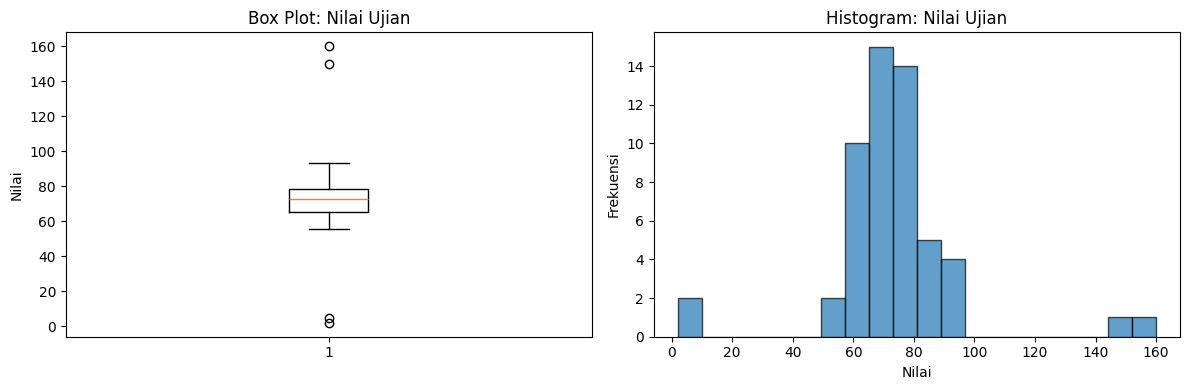

In [16]:
# Visualisasi untuk melihat outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
axes[0].boxplot(data_outlier['nilai_ujian'], vert=True)
axes[0].set_title('Box Plot: Nilai Ujian')
axes[0].set_ylabel('Nilai')

# Histogram
axes[1].hist(data_outlier['nilai_ujian'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_title('Histogram: Nilai Ujian')
axes[1].set_xlabel('Nilai')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### 4.1 Deteksi outlier dengan Z-Score

Z-Score menghitung berapa standar deviasi suatu titik data dari rata-rata. Umumnya, data dengan Z-Score di luar rentang -3 sampai +3 dianggap outlier.

In [17]:
# Menghitung Z-Score
z_scores = stats.zscore(data_outlier['nilai_ujian'])
outliers_zscore = abs(z_scores) > 3

print(f'Outlier terdeteksi (Z-Score > 3): {outliers_zscore.sum()} data')
print(f'Nilai outlier: {data_outlier[outliers_zscore]["nilai_ujian"].values}')

Outlier terdeteksi (Z-Score > 3): 4 data
Nilai outlier: [150.   5. 160.   2.]


### 4.2 Deteksi outlier dengan IQR

IQR adalah selisih antara kuartil ketiga (Q3, persentil 75) dan kuartil pertama (Q1, persentil 25). Data di bawah Q1 - 1.5*IQR atau di atas Q3 + 1.5*IQR dianggap outlier.

In [18]:
# Menghitung IQR
Q1 = data_outlier['nilai_ujian'].quantile(0.25)
Q3 = data_outlier['nilai_ujian'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers_iqr = (
    (data_outlier['nilai_ujian'] < batas_bawah) |
    (data_outlier['nilai_ujian'] > batas_atas)
)

print(f'Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}')
print(f'Batas bawah: {batas_bawah:.2f}, Batas atas: {batas_atas:.2f}')
print(f'Outlier terdeteksi (IQR): {outliers_iqr.sum()} data')
print(f'Nilai outlier: {data_outlier[outliers_iqr]["nilai_ujian"].values}')

Q1: 65.13, Q3: 78.68, IQR: 13.54
Batas bawah: 44.82, Batas atas: 98.99
Outlier terdeteksi (IQR): 4 data
Nilai outlier: [150.   5. 160.   2.]


In [19]:
# Menghapus outlier berdasarkan IQR
data_no_outlier = data_outlier[~outliers_iqr].copy()

print(f'Jumlah data sebelum: {len(data_outlier)}')
print(f'Jumlah data sesudah: {len(data_no_outlier)}')
print(f'Mean baru: {data_no_outlier["nilai_ujian"].mean():.2f}')

Jumlah data sebelum: 54
Jumlah data sesudah: 50
Mean baru: 72.75


## 5. Data Reduction

Ketika dataset memiliki banyak fitur (kolom), kompleksitas komputasi meningkat dan model bisa mengalami overfitting. Data reduction bertujuan mengurangi jumlah fitur sambil mempertahankan informasi penting.

Dua teknik yang akan kita praktikkan:

- **Feature Selection (SelectKBest)**: memilih K fitur terbaik berdasarkan uji statistik
- **PCA (Principal Component Analysis)**: mentransformasi fitur ke dimensi yang lebih rendah

In [20]:
# Dataset contoh
data_reduce = pd.DataFrame({
    'feature1': [10, 20, 30, 40, 50],
    'feature2': [1, 2, 3, 4, 5],
    'feature3': [100, 200, 300, 400, 500],
    'target': [0, 1, 0, 1, 0]
})

X = data_reduce[['feature1', 'feature2', 'feature3']]
y = data_reduce['target']

print('Dataset asli (3 fitur):')
print(X)

Dataset asli (3 fitur):
   feature1  feature2  feature3
0        10         1       100
1        20         2       200
2        30         3       300
3        40         4       400
4        50         5       500


In [21]:
# Feature Selection: memilih 2 fitur terbaik
selector = SelectKBest(chi2, k=2)
X_selected = selector.fit_transform(X, y)

# Menampilkan fitur mana yang terpilih
mask = selector.get_support()
selected_names = X.columns[mask].tolist()

print(f'Fitur terpilih: {selected_names}')
print(f'\nData setelah feature selection (2 fitur):')
print(X_selected)

Fitur terpilih: ['feature2', 'feature3']

Data setelah feature selection (2 fitur):
[[  1 100]
 [  2 200]
 [  3 300]
 [  4 400]
 [  5 500]]


In [22]:
# PCA: reduksi menjadi 2 komponen utama
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print('Data setelah PCA (2 komponen):')
print(X_pca.round(3))
print(f'\nVariansi yang dijelaskan tiap komponen: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variansi yang dipertahankan: {pca.explained_variance_ratio_.sum():.3f}')

Data setelah PCA (2 komponen):
[[-201.007   -0.   ]
 [-100.504    0.   ]
 [   0.      -0.   ]
 [ 100.504   -0.   ]
 [ 201.007   -0.   ]]

Variansi yang dijelaskan tiap komponen: [1. 0.]
Total variansi yang dipertahankan: 1.000


Perhatikan bahwa PCA berhasil mempertahankan hampir seluruh variansi data meskipun jumlah dimensi dikurangi dari 3 menjadi 2. Ini berarti hampir tidak ada informasi yang hilang.

## 6. Preprocessing Pipeline dengan scikit-learn

Pada proyek nyata, kita sering perlu menerapkan beberapa langkah preprocessing secara berurutan. Menulis setiap langkah secara terpisah rawan error dan sulit direproduksi. Scikit-learn menyediakan `Pipeline` dan `ColumnTransformer` yang memungkinkan kita menyusun seluruh langkah preprocessing menjadi satu objek yang bisa dijalankan secara konsisten.

Keuntungan menggunakan pipeline:

- Kode lebih rapi dan mudah dibaca
- Menghindari data leakage saat cross-validation
- Mudah direproduksi dan di-deploy

In [23]:
# Dataset contoh yang lebih realistis
data_pipeline = pd.DataFrame({
    'usia': [25, None, 35, 28, 42, None, 30, 38],
    'gaji': [5000000, 7000000, None, 6000000, 12000000, 8000000, None, 9000000],
    'kota': ['Jakarta', 'Bandung', 'Jakarta', 'Yogyakarta',
             'Jakarta', 'Bandung', 'Yogyakarta', 'Bandung'],
    'tingkat': ['junior', 'senior', 'mid', 'junior',
               'senior', 'mid', 'junior', 'senior']
})

print('Dataset awal:')
print(data_pipeline)
print(f'\nMissing values:\n{data_pipeline.isnull().sum()}')

Dataset awal:
   usia        gaji        kota tingkat
0  25.0   5000000.0     Jakarta  junior
1   NaN   7000000.0     Bandung  senior
2  35.0         NaN     Jakarta     mid
3  28.0   6000000.0  Yogyakarta  junior
4  42.0  12000000.0     Jakarta  senior
5   NaN   8000000.0     Bandung     mid
6  30.0         NaN  Yogyakarta  junior
7  38.0   9000000.0     Bandung  senior

Missing values:
usia       2
gaji       2
kota       0
tingkat    0
dtype: int64


In [24]:
# Mendefinisikan kolom numerik dan kategorikal
numeric_features = ['usia', 'gaji']
categorical_features = ['kota', 'tingkat']

# Pipeline untuk kolom numerik: imputasi + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline untuk kolom kategorikal: imputasi + encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Menggabungkan semua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Menjalankan seluruh preprocessing sekaligus
data_preprocessed = preprocessor.fit_transform(data_pipeline)

# Mendapatkan nama kolom hasil transformasi
cat_columns = preprocessor.named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_features).tolist()
all_columns = numeric_features + cat_columns

result = pd.DataFrame(data_preprocessed, columns=all_columns)
print('Hasil preprocessing dengan pipeline:')
print(result.round(3))

Hasil preprocessing dengan pipeline:
    usia   gaji  kota_Bandung  kota_Jakarta  kota_Yogyakarta  tingkat_junior  tingkat_mid  tingkat_senior
0 -1.569 -1.443           0.0           1.0              0.0             1.0          0.0             0.0
1  0.000 -0.424           1.0           0.0              0.0             0.0          0.0             1.0
2  0.392  0.000           0.0           1.0              0.0             0.0          1.0             0.0
3 -0.981 -0.934           0.0           0.0              1.0             1.0          0.0             0.0
4  1.765  2.122           0.0           1.0              0.0             0.0          0.0             1.0
5  0.000  0.085           1.0           0.0              0.0             0.0          1.0             0.0
6 -0.588  0.000           0.0           0.0              1.0             1.0          0.0             0.0
7  0.981  0.594           1.0           0.0              0.0             0.0          0.0             1.0


Dengan satu perintah `fit_transform`, seluruh langkah preprocessing (imputasi, scaling, dan encoding) diterapkan secara berurutan. Objek `preprocessor` juga bisa disimpan dan digunakan ulang untuk memproses data baru dengan cara yang sama.

---

## Latihan

Kerjakan latihan berikut untuk menguji pemahaman kalian tentang data preprocessing.

### Latihan 1: Data Cleaning

Diberikan dataset berikut. Lakukan:
1. Isi missing values pada kolom `score` dengan **median**
2. Hapus baris duplikat
3. Print hasilnya

```python
latihan1 = pd.DataFrame({
    'student': ['Dina', 'Eka', 'Fajar', 'Dina', 'Gita'],
    'score': [85, None, 72, 85, None],
    'grade': ['A', 'B', 'C', 'A', 'B']
})
```

In [25]:
# Tulis kode jawaban Latihan 1 di sini


### Latihan 2: Encoding

Gunakan dataset berikut:

```python
latihan2 = pd.DataFrame({
    'warna': ['merah', 'biru', 'hijau', 'merah', 'hijau'],
    'ukuran': ['kecil', 'sedang', 'besar', 'sedang', 'kecil'],
    'harga': [10000, 25000, 50000, 15000, 8000]
})
```

1. Terapkan **One-Hot Encoding** pada kolom `warna`
2. Terapkan **Ordinal Encoding** pada kolom `ukuran` (urutan: kecil < sedang < besar)
3. Print DataFrame hasil gabungan

In [26]:
# Tulis kode jawaban Latihan 2 di sini


### Latihan 3: Outlier Detection

Gunakan dataset berikut:

```python
np.random.seed(0)
latihan3 = pd.DataFrame({
    'pendapatan': np.concatenate([
        np.random.normal(5000000, 1000000, 30),
        np.array([50000000, 100000])
    ])
})
```

1. Deteksi outlier menggunakan metode **IQR**
2. Print jumlah outlier dan nilainya
3. Buat **box plot** sebelum dan sesudah menghapus outlier (gunakan `plt.subplots(1, 2)`)

In [27]:
# Tulis kode jawaban Latihan 3 di sini


### Latihan 4: Pipeline

Buat sebuah preprocessing pipeline menggunakan `ColumnTransformer` untuk dataset berikut:

```python
latihan4 = pd.DataFrame({
    'luas_m2': [36, None, 72, 45, 100, None],
    'kamar': [2, 3, None, 2, 4, 3],
    'lokasi': ['pusat', 'pinggiran', 'pusat', 'pinggiran', 'pusat', 'pinggiran'],
    'harga_juta': [500, 300, 900, 400, 1200, 350]
})
```

Pipeline harus melakukan:
- Kolom numerik (`luas_m2`, `kamar`): imputasi dengan **median**, lalu **MinMaxScaler**
- Kolom kategorikal (`lokasi`): imputasi dengan **most_frequent**, lalu **One-Hot Encoding**

Print DataFrame hasil preprocessing.

In [28]:
# Tulis kode jawaban Latihan 4 di sini


---

## Ringkasan

Pada tutorial ini kita telah mempelajari langkah-langkah utama dalam data preprocessing:

| Langkah | Teknik | Library/Fungsi |
|---------|--------|---------------|
| Data Cleaning | Imputasi, hapus duplikat, perbaiki format | `SimpleImputer`, `drop_duplicates()`, `to_datetime()` |
| Data Integration | Merge/join tabel | `pd.merge()` |
| Data Transformation | Scaling, encoding | `StandardScaler`, `MinMaxScaler`, `OneHotEncoder`, `LabelEncoder`, `OrdinalEncoder` |
| Outlier Detection | Z-Score, IQR | `scipy.stats.zscore()`, `quantile()` |
| Data Reduction | Feature selection, PCA | `SelectKBest`, `PCA` |
| Pipeline | Otomatisasi preprocessing | `Pipeline`, `ColumnTransformer` |

**Poin penting:**

- Data preprocessing bukan proses sekali jalan. Seiring model berkembang, langkah preprocessing perlu dievaluasi dan diperbaiki.
- Gunakan pipeline untuk menjaga konsistensi dan reproducibility.
- Selalu pahami data terlebih dahulu (exploratory data analysis) sebelum memilih teknik preprocessing.
- Dokumentasikan setiap langkah preprocessing yang dilakukan.

---

## Upload ke GitHub

1. Buat repository baru di GitHub (atau gunakan repository yang sudah ada)
2. Clone repository:
   ```
   git clone https://github.com/username/repo-name.git
   ```
3. Salin file notebook ini ke dalam folder repository
4. Commit dan push:
   ```
   git add tutorial-data-preprocessing.ipynb
   git commit -m "Tambah tutorial data preprocessing"
   git push origin main
   ```